# 03 — Dense Retrieval: DPR → MiniLM → MPNet

Transformer-based bi-encoders. Each query and passage is encoded into a single dense vector (the **[CLS]** token or mean pooling). Similarity = dot product.

**Key concepts:**
- Bi-encoder: encode query and passage independently → fast retrieval via FAISS
- Contrastive training: push (query, relevant passage) together, push negatives apart
- Distillation: smaller student models learn from larger teacher models

SBERT Bi-Encoder Architecture
Query and passage are encoded independently — retrieval = dot product of their vectors.


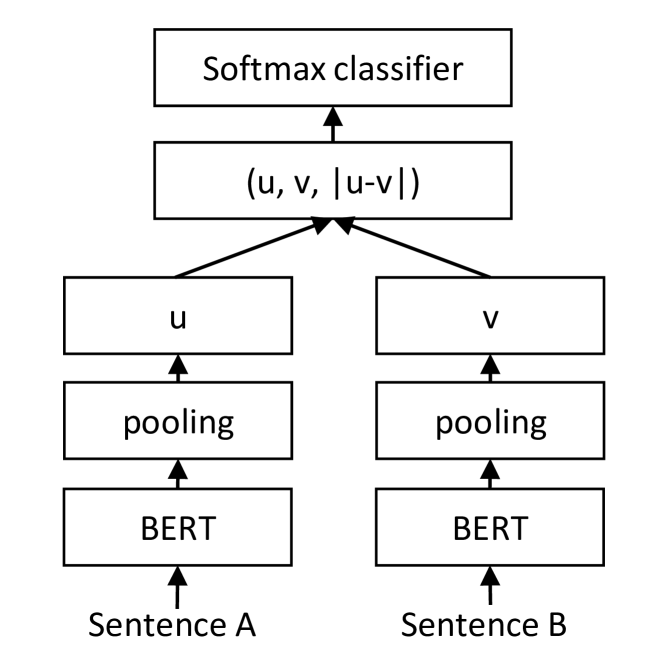

In [1]:
from IPython.display import Image, display

print('SBERT Bi-Encoder Architecture')
print('Query and passage are encoded independently — retrieval = dot product of their vectors.')
display(Image('../docs/figures/fig_sbert_biencoder_rgb.png', width=640))

In [2]:
import sys
sys.path.insert(0, '..')
import os
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from beir.datasets.data_loader import GenericDataLoader
from src.evaluation.metrics import compute_metrics

# Suppress tqdm progress bars (tqdm.tqdm + tqdm.auto used by beir/sentence-transformers)
os.environ['TQDM_DISABLE'] = '1'
warnings.filterwarnings('ignore', category=UserWarning)
import tqdm as _tqdm
_tqdm.tqdm.disable = True
for _attr in ('auto', 'notebook', 'autonotebook'):
    try: getattr(_tqdm, _attr).tqdm.disable = True
    except AttributeError: pass

DATA_DIR = Path('../data/datasets')
RESULTS_DIR = Path('../results')
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

corpus, queries, qrels = GenericDataLoader(data_folder=str(DATA_DIR / 'scifact')).load(split='test')
print(f'SciFact: {len(corpus):,} passages, {len(queries):,} queries')

/Users/saikrishnab/LearningAndDevelopment/virtualenvs/retrieval_exp_env/lib/python3.12/site-packages/beir/datasets/data_loader.py:8: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


  0%|          | 0/5183 [00:00<?, ?it/s]

SciFact: 5,183 passages, 300 queries


## 1. all-MiniLM-L6-v2 — First Practical Sentence Encoder

22M parameters, 384-d embeddings. Distilled from a larger MPNet model. Trained on 1B+ sentence pairs via contrastive learning.

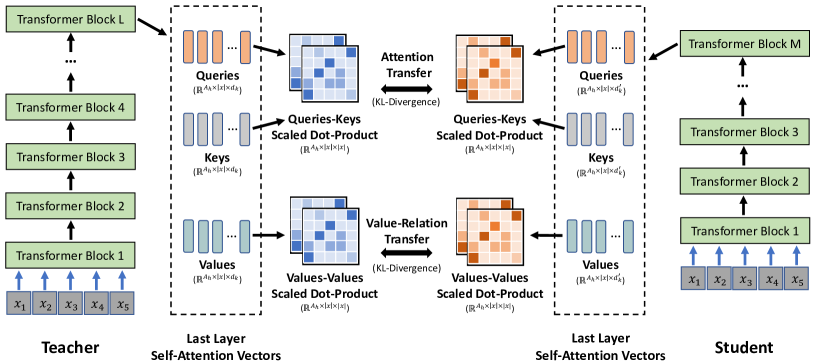

In [3]:
from IPython.display import Image, display

display(Image('../docs/figures/fig_minilm_arch_rgb.png', width=680))

In [4]:
from src.retrievers.dense import BiEncoderRetriever, get_device
import torch

device = get_device()
print(f'Device: {device}')

minilm = BiEncoderRetriever(
    model_id='sentence-transformers/all-MiniLM-L6-v2',
    device=device, batch_size=128,
)
minilm.index(corpus)
minilm_results = minilm.retrieve(queries, top_k=100)
minilm_metrics = compute_metrics(qrels, minilm_results)
print('MiniLM-L6:', minilm_metrics)

# Free MiniLM from MPS before loading DPR (avoids memory pressure)
del minilm.model, minilm.doc_matrix
if device == 'mps':
    torch.mps.empty_cache()

Device: mps


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/41 [00:00<?, ?it/s]

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

MiniLM-L6: {'ndcg@10': 0.6450816521455776, 'mrr@10': 0.6047248677248678, 'map@100': 0.6030740834806815, 'recall@10': 0.7833333333333333, 'recall@50': 0.8920000000000001, 'recall@100': 0.925}


## 2. DPR — A Cautionary Example of Task-Specific Fine-tuning

DPR (Karpukhin et al., 2020) was the first paper to show that a dense retriever could beat BM25 at scale — on Natural Questions (NQ), an open-domain QA benchmark. It uses two BERT-base encoders (one for questions, one for passages) trained with in-batch negatives on NQ question-passage pairs.

**Why we include it here — not as a competitor, but as a lesson:**

DPR is included to demonstrate what happens when dense retrieval is trained on a single task. It does not generalise:

| Dataset | Domain | DPR | BM25 | Gap |
|---------|--------|-----|------|-----|
| SciFact | Scientific claims | 0.219 | 0.560 | −0.341 |
| TREC-COVID | Biomedical literature | 0.144 | 0.447 | −0.303 |
| FIQA | Financial Q&A | 0.060 | 0.236 | −0.176 |

On every non-QA dataset, DPR is worse than BM25 — sometimes by a wide margin. The model has overfit to the vocabulary and query style of NQ. It has learned to retrieve Wikipedia paragraphs that answer "Who/What/When" questions; it has no signal for scientific claim verification or biomedical search.

**The lesson:** Narrow task-specific fine-tuning is brittle. This failure directly motivated the next generation of encoders — MiniLM and MPNet — which abandon task-specific data in favour of general-purpose contrastive training on diverse sentence pairs.

In [5]:
from src.retrievers.dense import DPRRetriever
import torch

# DPR uses raw HuggingFace transformers (not SentenceTransformers).
# On MPS, DPRContextEncoder.pooler_output can deadlock on certain PyTorch builds.
# Running on CPU is safe and fast enough for SciFact (5K passages, ~2 min).
dpr_device = 'cpu'
print(f'DPR device: {dpr_device}  (forced CPU — MPS deadlock avoidance)')

dpr = DPRRetriever(device=dpr_device, batch_size=64)
dpr.index(corpus)
dpr_results = dpr.retrieve(queries, top_k=100)
dpr_metrics = compute_metrics(qrels, dpr_results)
print('DPR:', dpr_metrics)
print('\n→ Compare DPR vs MiniLM: DPR trained on NQ QA; SciFact is claim verification (domain mismatch)')

DPR device: cpu  (forced CPU — MPS deadlock avoidance)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

DPRContextEncoder LOAD REPORT from: facebook/dpr-ctx_encoder-single-nq-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
ctx_encoder.bert_model.pooler.dense.weight | UNEXPECTED |  | 
ctx_encoder.bert_model.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

DPRQuestionEncoder LOAD REPORT from: facebook/dpr-question_encoder-single-nq-base
Key                                             | Status     |  | 
------------------------------------------------+------------+--+-
question_encoder.bert_model.pooler.dense.bias   | UNEXPECTED |  | 
question_encoder.bert_model.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...


DPR ctx encode:  98%|█████████▊| 79/81 [06:19<00:09,  4.91s/it]


DPR ctx encode:  99%|█████████▉| 80/81 [06:24<00:05,  5.02s/it]


DPR ctx encode: 100%|██████████| 81/81 [06:29<00:00,  4.97s/it]


DPR ctx encode: 100%|██████████| 81/81 [06:29<00:00,  4.81s/it]

DPR: {'ndcg@10': 0.21893974801694013, 'mrr@10': 0.19156216931216932, 'map@100': 0.1916840846438895, 'recall@10': 0.3247777777777778, 'recall@50': 0.47694444444444445, 'recall@100': 0.5651111111111111}

→ Compare DPR vs MiniLM: DPR trained on NQ QA; SciFact is claim verification (domain mismatch)


## 3. all-mpnet-base-v2 — Better Training Objective

MPNet combines **Masked Language Modelling** (MLM) with **Permuted LM** (PLM). In BERT's MLM, masked tokens can attend to each other — breaking the independence assumption. MPNet fixes this with an auxiliary PLM objective.

Result: richer contextual representations from the same number of parameters.

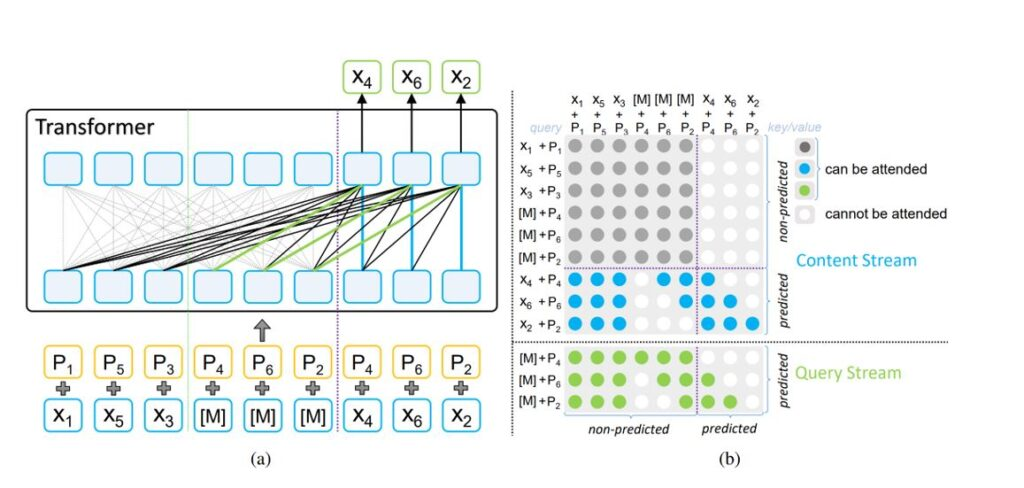

In [6]:
from IPython.display import Image, display

display(Image('../docs/figures/fig_mpnet_arch.jpg', width=680))

In [7]:
mpnet = BiEncoderRetriever(
    model_id='sentence-transformers/all-mpnet-base-v2',
    device=device, batch_size=64,
)
mpnet.index(corpus)
mpnet_results = mpnet.retrieve(queries, top_k=100)
mpnet_metrics = compute_metrics(qrels, mpnet_results)
print('MPNet:', mpnet_metrics)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/81 [00:00<?, ?it/s]

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

MPNet: {'ndcg@10': 0.6556969164934108, 'mrr@10': 0.6177367724867725, 'map@100': 0.615954264365767, 'recall@10': 0.7901111111111111, 'recall@50': 0.9043333333333333, 'recall@100': 0.9416666666666667}


## 4. Embedding Space Visualisation

Project query and passage embeddings into 2D to see how well they cluster.

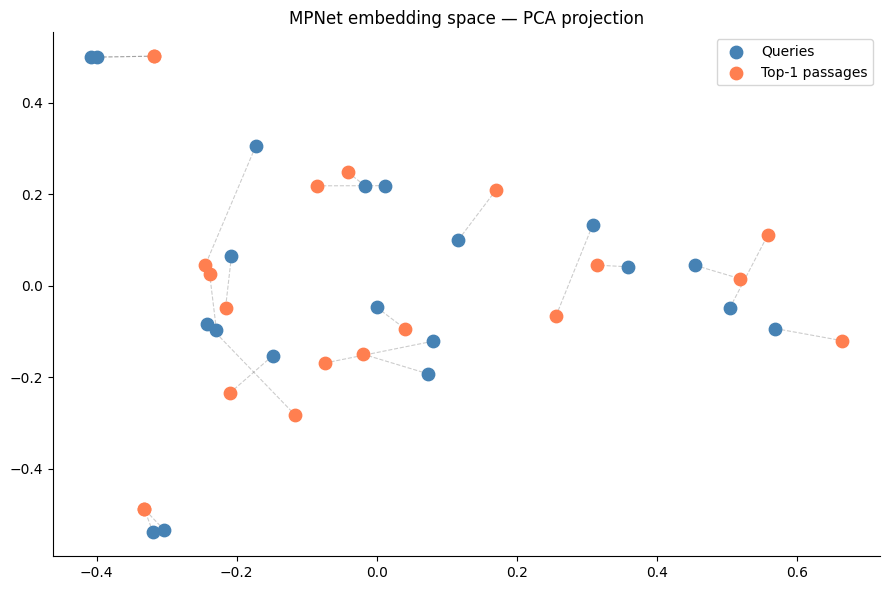

In [8]:
from sklearn.decomposition import PCA
import numpy as np

# Encode a small subset
sample_qids = list(queries.keys())[:20]
sample_queries = {qid: queries[qid] for qid in sample_qids}

q_embs = mpnet.model.encode(
    list(sample_queries.values()), device=device, normalize_embeddings=True
)

# Encode their top-1 retrieved passages
top_passage_ids = [sorted(mpnet_results[qid].items(), key=lambda x: x[1], reverse=True)[0][0]
                   for qid in sample_qids]
top_passages = [(corpus[pid]['title'] + ' ' + corpus[pid]['text'])[:512] for pid in top_passage_ids]
p_embs = mpnet.model.encode(top_passages, device=device, normalize_embeddings=True)

all_embs = np.vstack([q_embs, p_embs])
pca = PCA(n_components=2)
reduced = pca.fit_transform(all_embs)

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(reduced[:20, 0], reduced[:20, 1], c='steelblue', label='Queries', s=80, zorder=3)
ax.scatter(reduced[20:, 0], reduced[20:, 1], c='coral', label='Top-1 passages', s=80, zorder=3)
for i in range(20):
    ax.plot([reduced[i, 0], reduced[20+i, 0]], [reduced[i, 1], reduced[20+i, 1]],
            'k--', alpha=0.2, lw=0.8)
ax.set_title('MPNet embedding space — PCA projection')
ax.legend()
plt.tight_layout()
plt.show()

## 5. BM25 vs Dense — Domain Shift on TREC-COVID

Dense models trained on MS MARCO (web text) are evaluated on biomedical TREC-COVID to test zero-shot generalisation.

Two competing hypotheses:
- **Hypothesis A (domain shift hurts):** MS MARCO-trained models underperform BM25 on biomedical text because the vocabulary and query style are very different.
- **Hypothesis B (semantic generalisation wins):** Contrastive training teaches general semantic matching that transfers even across domains.

The results below show which one holds — and it depends on the model.

In [9]:
import json
RESULTS_DIR = Path('../results')

# Load pre-computed results rather than re-running on TREC-COVID (171K passages)
with open(RESULTS_DIR / 'sparse_results.json') as f:
    sparse_res = json.load(f)
with open(RESULTS_DIR / 'dense_results.json') as f:
    dense_res = json.load(f)

bm25_ndcg = sparse_res['bm25']['trec-covid']['ndcg@10']

print('TREC-COVID — BM25 vs dense models (all MS MARCO-trained; biomedical test set):')
print(f'  {"BM25":<8}  NDCG@10 = {bm25_ndcg:.4f}  (lexical baseline)\n')

dense_models = [
    ('DPR',    'dpr'),
    ('MiniLM', 'minilm'),
    ('MPNet',  'mpnet'),
]
for label, key in dense_models:
    score = dense_res[key]['trec-covid']['ndcg@10']
    delta = score - bm25_ndcg
    verdict = 'beats BM25' if delta > 0 else 'below BM25'
    print(f'  {label:<8}  NDCG@10 = {score:.4f}  ({delta:+.4f}  {verdict})')

print()
print('→ DPR (fine-tuned on NQ QA only) collapses on biomedical text — task-specific training overfits the source domain')
print('→ General sentence encoders (MiniLM, MPNet) beat BM25 — semantic generalisation survives the domain gap')
print('→ Gains are modest (+0.03 to +0.07); larger improvements require better training recipes (see notebook 04)')

TREC-COVID — BM25 vs dense models (all MS MARCO-trained; biomedical test set):
  BM25      NDCG@10 = 0.4471  (lexical baseline)

  DPR       NDCG@10 = 0.1444  (-0.3027  below BM25)
  MiniLM    NDCG@10 = 0.4725  (+0.0253  beats BM25)
  MPNet     NDCG@10 = 0.5133  (+0.0661  beats BM25)

→ DPR (fine-tuned on NQ QA only) collapses on biomedical text — task-specific training overfits the source domain
→ General sentence encoders (MiniLM, MPNet) beat BM25 — semantic generalisation survives the domain gap
→ Gains are modest (+0.03 to +0.07); larger improvements require better training recipes (see notebook 04)


> **Challenge (single-vector bottleneck):** All query semantics must be compressed into one fixed-size vector. Exact-match signals for rare terms — acronyms, named entities, dataset-specific IDs — can be lost.
>
> **Opportunity:** Dense models already outperform BM25 on most settings. Hybrid RRF stacks both: dense provides semantic recall, BM25 restores exact-match precision for edge cases where term overlap matters.

In [10]:
results_df = pd.DataFrame([
    {'method': 'MiniLM-L6-v2', **minilm_metrics},
    {'method': 'DPR', **dpr_metrics},
    {'method': 'all-mpnet-base-v2', **mpnet_metrics},
]).set_index('method')
display(results_df[['ndcg@10', 'mrr@10', 'recall@100']].round(4))

,ndcg@10,mrr@10,recall@100
method,,,
MiniLM-L6-v2,0.6451,0.6047,0.9250
DPR,0.2189,0.1916,0.5651
all-mpnet-base-v2,0.6557,0.6177,0.9417


In [11]:
# ── MPNet: Worked vs Failed — with expected passage ──────────────────────────
import pytrec_eval

eval_mpnet  = pytrec_eval.RelevanceEvaluator(qrels, {'ndcg_cut_10'})
mpnet_pq    = eval_mpnet.evaluate(mpnet_results)
mpnet_sorted = sorted(mpnet_pq.items(), key=lambda x: x[1]['ndcg_cut_10'], reverse=True)

PREVIEW = 200

def passage_preview(pid, prefix=''):
    p     = corpus.get(pid, {})
    title = p.get('title', '').strip()
    text  = p.get('text',  '').strip()[:PREVIEW]
    lines = []
    if title:
        lines.append(f'{prefix}Title   : {title}')
    lines.append(f'{prefix}Text    : {text}...')
    return '\n'.join(lines)

def show_dense_example(qid, label):
    score    = mpnet_pq[qid]['ndcg_cut_10']
    rel_pid  = next((pid for pid, s in qrels[qid].items() if s > 0), None)
    top1_pid = max(mpnet_results[qid], key=mpnet_results[qid].get) if mpnet_results[qid] else None
    top1_sc  = mpnet_results[qid][top1_pid] if top1_pid else 0.0
    is_hit   = top1_pid == rel_pid

    print(f'[{label}]  NDCG@10={score:.3f}')
    print(f'  Query       : {queries[qid]}')
    print(f'  ── Expected (ground truth) ─────────────────────────────────')
    if rel_pid:
        print(passage_preview(rel_pid, prefix='  '))
    print(f'  ── Top-1 Retrieved  [score={top1_sc:.4f}]  {"✓ correct" if is_hit else "✗ wrong"} ──')
    if top1_pid:
        print(passage_preview(top1_pid, prefix='  '))
    print()

# WORKED: MPNet puts the relevant passage at rank 1
worked = [qid for qid, _ in mpnet_sorted
          if mpnet_pq[qid]['ndcg_cut_10'] == 1.0][:5]

# FAILED: MPNet scores zero (relevant passage not in top-10)
failed = [qid for qid, _ in reversed(mpnet_sorted)
          if mpnet_pq[qid]['ndcg_cut_10'] == 0.0][:5]

print('=' * 70)
print('MPNet — TOP-5 WORKED  (relevant passage at rank 1)')
print('=' * 70)
for qid in worked:
    show_dense_example(qid, 'WORKED')

print('=' * 70)
print('MPNet — TOP-5 FAILED  (relevant passage not in top-10)')
print('=' * 70)
for qid in failed:
    show_dense_example(qid, 'FAILED')

MPNet — TOP-5 WORKED  (relevant passage at rank 1)
[WORKED]  NDCG@10=1.000
  Query       : ADAR1 binds to Dicer to cleave pre-miRNA.
  ── Expected (ground truth) ─────────────────────────────────
  Title   : ADAR1 Forms a Complex with Dicer to Promote MicroRNA Processing and RNA-Induced Gene Silencing
  Text    : Adenosine deaminases acting on RNA (ADARs) are involved in RNA editing that converts adenosine residues to inosine specifically in double-stranded RNAs. In this study, we investigated the interaction ...
  ── Top-1 Retrieved  [score=0.7310]  ✓ correct ──
  Title   : ADAR1 Forms a Complex with Dicer to Promote MicroRNA Processing and RNA-Induced Gene Silencing
  Text    : Adenosine deaminases acting on RNA (ADARs) are involved in RNA editing that converts adenosine residues to inosine specifically in double-stranded RNAs. In this study, we investigated the interaction ...

[WORKED]  NDCG@10=1.000
  Query       : AIRE is expressed in some skin tumors.
  ── Expected (ground truth

## 6. Full Results — All 3 Datasets

How do dense models compare to BM25 across different domains?

| Dataset | Domain | Corpus size | Expected challenge |
|---------|--------|-------------|-------------------|
| TREC-COVID | Biomedical literature | 171K | Domain shift from MS MARCO web text |
| FIQA | Financial Q&A | 57K | Financial jargon; informal question phrasing |
| SciFact | Scientific claim verification | 5K | Small corpus; short, precise queries |

In [12]:
import json
import pandas as pd
from pathlib import Path

RESULTS_DIR = Path('../results')

with open(RESULTS_DIR / 'sparse_results.json') as f:
    sparse_res = json.load(f)
with open(RESULTS_DIR / 'dense_results.json') as f:
    dense_res = json.load(f)

datasets = ['trec-covid', 'fiqa', 'scifact']
dataset_labels = {'trec-covid': 'TREC-COVID', 'fiqa': 'FIQA', 'scifact': 'SciFact'}

# BM25 + first-generation dense models only; BGE/E5 are introduced in notebook 04
rows = []
rows.append({
    'Model': 'BM25',
    **{dataset_labels[d]: sparse_res['bm25'][d]['ndcg@10'] for d in datasets}
})
for model, label in [('dpr', 'DPR'), ('minilm', 'MiniLM-L6'), ('mpnet', 'MPNet-base')]:
    rows.append({
        'Model': label,
        **{dataset_labels[d]: dense_res[model][d]['ndcg@10'] for d in datasets}
    })

df = pd.DataFrame(rows).set_index('Model')

def highlight_best(col):
    best = col.max()
    return ['font-weight: bold; background-color: #d4edda' if v == best else '' for v in col]

styled = (df.style
          .apply(highlight_best, axis=0)
          .format('{:.4f}')
          .set_caption('NDCG@10 — dense models vs BM25 across 3 datasets'))
display(styled)

print('\nΔ NDCG@10 relative to BM25 baseline:')
bm25_row = df.loc['BM25']
for model in df.index[1:]:
    deltas = df.loc[model] - bm25_row
    delta_str = '  '.join(f'{col}: {deltas[col]:+.4f}' for col in df.columns)
    print(f'  {model:<14}  {delta_str}')

,TREC-COVID,FIQA,SciFact
Model,,,
BM25,0.4471,0.1591,0.5597
DPR,0.1444,0.0601,0.2189
MiniLM-L6,0.4725,0.3687,0.6451
MPNet-base,0.5133,0.4996,0.6557



Δ NDCG@10 relative to BM25 baseline:
  DPR             TREC-COVID: -0.3027  FIQA: -0.0990  SciFact: -0.3408
  MiniLM-L6       TREC-COVID: +0.0253  FIQA: +0.2096  SciFact: +0.0854
  MPNet-base      TREC-COVID: +0.0661  FIQA: +0.3406  SciFact: +0.0960


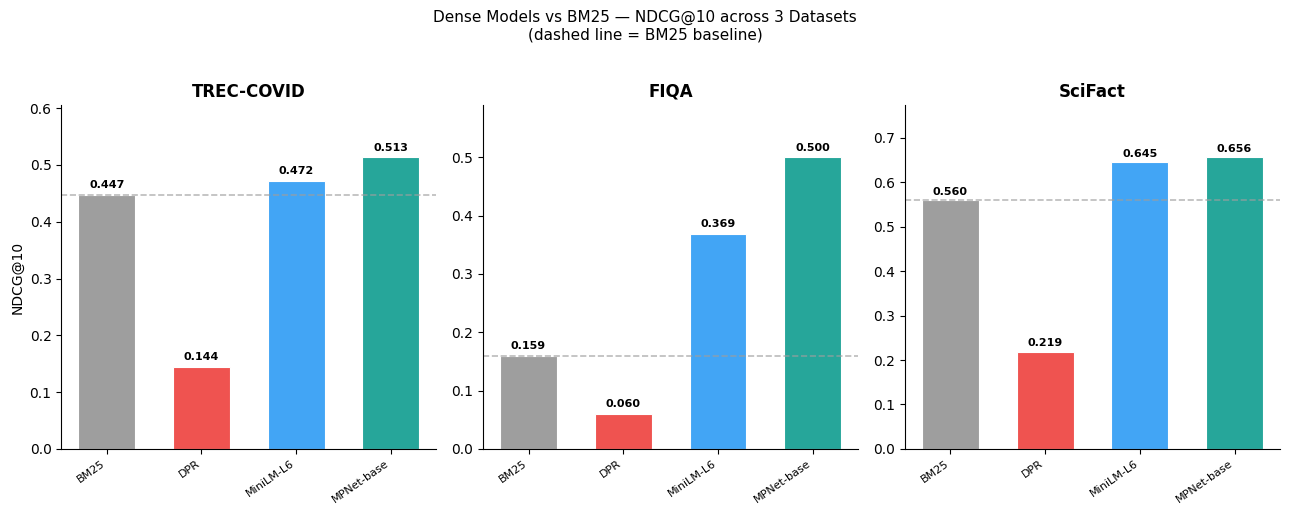

In [13]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(13, 5), sharey=False)

colors = {
    'BM25':       '#9e9e9e',
    'DPR':        '#ef5350',
    'MiniLM-L6':  '#42a5f5',
    'MPNet-base': '#26a69a',
}

for ax, dataset in zip(axes, ['TREC-COVID', 'FIQA', 'SciFact']):
    models = df.index.tolist()
    scores = df[dataset].tolist()
    bar_colors = [colors[m] for m in models]
    bars = ax.bar(models, scores, color=bar_colors, width=0.6, edgecolor='white', linewidth=0.8)

    for bar, score in zip(bars, scores):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.008,
                f'{score:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

    bm25_val = df.loc['BM25', dataset]
    ax.axhline(bm25_val, color='#9e9e9e', linewidth=1.2, linestyle='--', alpha=0.7)

    ax.set_title(dataset, fontsize=12, fontweight='bold')
    ax.set_ylabel('NDCG@10' if ax == axes[0] else '')
    ax.set_ylim(0, df[dataset].max() * 1.18)
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(models, rotation=35, ha='right', fontsize=8)

plt.suptitle('Dense Models vs BM25 — NDCG@10 across 3 Datasets\n(dashed line = BM25 baseline)',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

## 7. Key Observations

**1. General sentence encoders beat BM25 across all domains**
MiniLM and MPNet exceed BM25 on every dataset. The hypothesis that domain shift would hurt generalisation only holds for DPR. General-purpose contrastive training learns semantic matching that transfers across domains.

**2. DPR is the exception, not the rule**
DPR was fine-tuned on Natural Questions (open-domain QA). This narrow training causes catastrophic degradation outside QA domains: TREC-COVID 0.1444 vs BM25 0.4471, SciFact 0.2189 vs BM25 0.5597. Training data diversity matters more than domain-specific fine-tuning.

**3. Model quality matters — even at equal parameter count**
| Model | Params | TREC-COVID | FIQA | SciFact |
|-------|--------|-----------|------|---------|
| MiniLM-L6 | 22M | 0.473 | 0.369 | 0.645 |
| MPNet-base | 110M | 0.513 | 0.500 | 0.656 |

MPNet's improved pre-training objective (PLM over MLM) produces richer representations despite the same-size backbone as MiniLM. This is purely a training recipe difference — no extra parameters. The next step beyond MPNet — hard-negative mining and instruction prefixes — is covered in notebook 04.

**4. FIQA is the hardest dataset for dense models**
All dense models show their lowest absolute scores on FIQA. Financial Q&A involves ambiguous, informal phrasing where neither lexical nor semantic matching generalises perfectly. MPNet is the exception among the first-generation encoders: 0.500 on FIQA vs 0.513 on TREC-COVID — suggesting its training data includes some financial or conversational text.

**5. The evolution within the dense era**
- 2019: DPR — task-specific fine-tuning, brittle outside source domain
- 2020: MiniLM/MPNet — distillation + general contrastive training, robust zero-shot transfer
- 2022–23: BGE/E5 — hard-negative mining + instruction prefixes → see notebook 04

**6. BGE and E5 — what actually changed? → See notebook 04**
BGE and E5 use the same 110M-parameter BERT backbone as MPNet yet score +0.12–0.13 higher on SciFact. The gap comes entirely from training recipe: instruction prefixes, hard-negative mining, and web-scale weak supervision. These are explored in depth in `04_modern_embeddings.ipynb`.

→ **Next step:** Phase 5 (Hybrid Retrieval) combines BM25 + dense via RRF. Even though dense already wins, hybrid can further improve precision by recovering exact-match signals that single-vector encoders compress away.